# Treinamento Não Supervisionado

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [39]:
df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")
df

,DAY_OF_WEEK,AIRLANE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ORIGIN_STATE_NAME,ORIGIN_COUNTRY_NAME,ORIGIN_LATITUDE_NAME,ORIGIN_LONGITUDE_NAME,DESTINATION_AIRPORT_NAME,DESTINATION_CITY_NAME,DESTINATION_STATE_NAME,DESTINATION_COUNTRY_NAME,DESTINATION_LATITUDE_NAME,DESTINATION_LONGITUDE_NAME
0,4,AS,98,N407AS,ANC,SEA,5,2354,-11.0,21.0,...,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,4,AA,2336,N3KUAA,LAX,PBI,10,2,-8.0,12.0,...,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,4,US,840,N171US,SFO,CLT,20,18,-2.0,16.0,...,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,4,AA,258,N3HYAA,LAX,MIA,20,15,-5.0,15.0,...,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,4,AS,135,N527AS,SEA,ANC,25,24,-1.0,11.0,...,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5332909,4,B6,688,N657JB,LAX,BOS,2359,2355,-4.0,22.0,...,CA,USA,33.94254,-118.40807,Gen. Edward Lawrence Logan International Airport,Boston,MA,USA,42.36435,-71.00518
5332910,4,B6,745,N828JB,JFK,PSE,2359,2355,-4.0,17.0,...,NY,USA,40.63975,-73.77893,Mercedita Airport,Ponce,PR,USA,18.00830,-66.56301
5332911,4,B6,1503,N913JB,JFK,SJU,2359,2350,-9.0,17.0,...,NY,USA,40.63975,-73.77893,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183
5332912,4,B6,333,N527JB,MCO,SJU,2359,2353,-6.0,10.0,...,FL,USA,28.42889,-81.31603,Luis Muñoz Marín International Airport,San Juan,PR,USA,18.43942,-66.00183


In [40]:
df.isnull().sum()

DAY_OF_WEEK                         0
AIRLANE_CODE                        0
FLIGHT_NUMBER                       0
TAIL_NUMBER                     14367
ORIGIN_AIRPORT                      0
DESTINATION_AIRPORT                 0
SCHEDULED_DEPARTURE                 0
DEPARTURE_TIME                      0
DEPARTURE_DELAY                 83814
TAXI_OUT                        86612
SCHEDULED_TIME                      6
ELAPSED_TIME                   101784
AIR_TIME                       101784
DISTANCE                            0
TAXI_IN                         89942
SCHEDULED_ARRIVAL                   0
ARRIVAL_TIME                        0
ARRIVAL_DELAY                  101784
DIVERTED                            0
CANCELLED                           0
CANCELLATION_REASON           5245484
AIR_SYSTEM_DELAY              4329554
SECURITY_DELAY                4329554
AIRLINE_DELAY                 4329554
LATE_AIRCRAFT_DELAY           4329554
WEATHER_DELAY                 4329554
DATE        

In [41]:
# Coluna para usar como base de treinamento

features = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "DISTANCE",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "SCHEDULED_TIME"
]

In [42]:
# Colunas derivadas para enriquecer o dataset

df["DELAY_TOTAL"] = df["DEPARTURE_DELAY"] + df["ARRIVAL_DELAY"]
df["TAXI_TOTAL"] = df["TAXI_OUT"] + df["TAXI_IN"]
df["DELAY_RATIO"] = df["ARRIVAL_DELAY"] / (df["ELAPSED_TIME"] + 1)
df["EFFICIENCY"] = df["AIR_TIME"] / (df["ELAPSED_TIME"] + 1)
df["DISTANCE_PER_MIN"] = df["DISTANCE"] / (df["AIR_TIME"] + 1)

In [43]:
df_features = df[features + ["DELAY_TOTAL", "TAXI_TOTAL", "DELAY_RATIO", "EFFICIENCY", "DISTANCE_PER_MIN"]]
df_features.head()

,DEPARTURE_DELAY,ARRIVAL_DELAY,DISTANCE,TAXI_OUT,TAXI_IN,AIR_TIME,SCHEDULED_TIME,DELAY_TOTAL,TAXI_TOTAL,DELAY_RATIO,EFFICIENCY,DISTANCE_PER_MIN
0,-11.0,-22.0,1448,21.0,4.0,169.0,205.0,-33.0,25.0,-0.112821,0.866667,8.517647
1,-8.0,-9.0,2330,12.0,4.0,263.0,280.0,-17.0,16.0,-0.032143,0.939286,8.825758
2,-2.0,5.0,2296,16.0,11.0,266.0,286.0,3.0,27.0,0.017007,0.904762,8.599251
3,-5.0,-9.0,2342,15.0,8.0,258.0,285.0,-14.0,23.0,-0.031915,0.914894,9.042471
4,-1.0,-21.0,1448,11.0,5.0,199.0,235.0,-22.0,16.0,-0.097222,0.921296,7.240000


In [67]:
df_features.columns

Index(['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'TAXI_OUT', 'TAXI_IN',
       'AIR_TIME', 'SCHEDULED_TIME', 'DELAY_TOTAL', 'TAXI_TOTAL',
       'DELAY_RATIO', 'EFFICIENCY', 'DISTANCE_PER_MIN'],
      dtype='object')

In [44]:
df_features.shape

(5332914, 12)

In [45]:
X = df_features[features].dropna()

In [46]:
# Padronização dos dados

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)


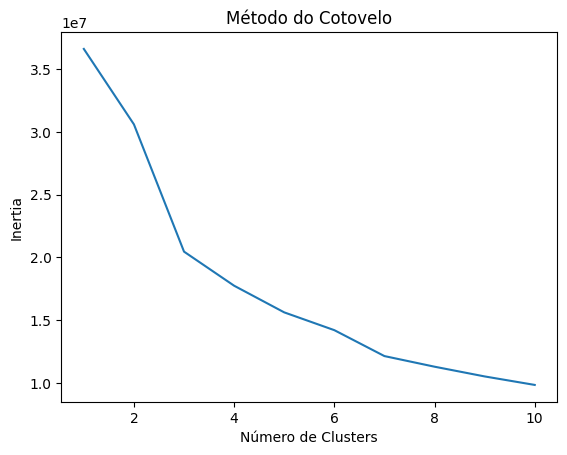

In [48]:
plt.figure()
plt.plot(range(1, 11), inertia)
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.show()

In [90]:
# Usando o PCA para reduzir a dimensionalidade e visualizar os clusters

pca = PCA(n_components=0.95)  # mantém 95% da variância
X_pca = pca.fit_transform(X_scaled)

print("Número de componentes:", pca.n_components_)

Número de componentes: 5


In [ ]:
# Tentnado com 3 clusters

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

X["cluster"] = clusters

In [64]:
score = silhouette_score(X_pca, clusters, sample_size=75000, random_state=42)
print("Silhouette Score:", score)

Silhouette Score: 0.45447098404902975


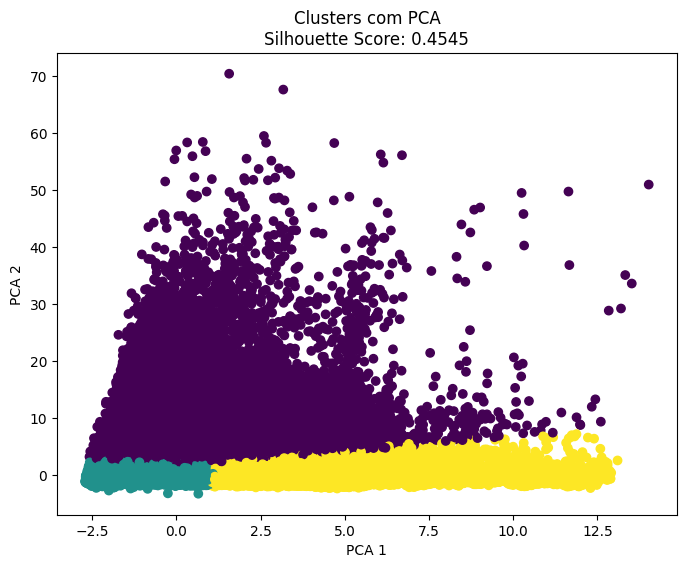

In [66]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title(f'Clusters com PCA\nSilhouette Score: {score:.4f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### Segmentando por Aeroporto

In [69]:
df_airport = df.groupby('ORIGIN_AIRPORT').agg({
    'DEPARTURE_DELAY': 'mean',
    'ARRIVAL_DELAY': 'mean',
    'TAXI_OUT': 'mean',
    'TAXI_IN': 'mean',
    'AIR_TIME': 'mean',
    'DISTANCE': 'mean',
    'DELAY_RATIO': 'mean',
    'EFFICIENCY': 'mean'
}).reset_index()

In [70]:
df_airport

,ORIGIN_AIRPORT,DEPARTURE_DELAY,ARRIVAL_DELAY,TAXI_OUT,TAXI_IN,AIR_TIME,DISTANCE,DELAY_RATIO,EFFICIENCY
0,ABE,8.844812,6.249663,13.408949,8.460161,98.433318,597.461741,0.046148,0.814260
1,ABI,5.783989,3.272075,9.188004,10.685932,34.076647,158.000000,0.023871,0.634680
2,ABQ,8.877015,4.768263,11.987672,7.670164,96.935511,706.949041,0.042598,0.812561
3,ABR,10.101056,9.909502,16.600302,7.717949,45.259427,257.000000,0.133034,0.650636
4,ABY,8.880046,7.587760,12.084198,7.794694,34.458430,145.000000,0.108572,0.633230
...,...,...,...,...,...,...,...,...,...
317,WRG,3.091884,4.667180,7.820827,4.178737,16.172573,56.500000,0.132271,0.550154
318,WYS,1.375000,-1.865385,11.903846,5.975962,47.062500,273.000000,-0.036680,0.715966
319,XNA,11.886184,11.233850,14.681277,11.446472,79.839116,529.186039,0.093727,0.739266
320,YAK,-6.292237,-5.632308,7.919330,3.935385,35.733846,205.954683,-0.131509,0.741958


In [71]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_airport.drop(columns=['ORIGIN_AIRPORT']))

In [82]:
# Tentnado com 3 clusters e avaliando o silhouette score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, clusters)

df_airport['cluster'] = clusters

print("Silhouette Score:", score)

Silhouette Score: 0.22920001077336827


In [88]:
for i in range(2, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, clusters)

    print(f"Clusters: {i}, Silhouette Score: {score:.4f}")

Clusters: 2, Silhouette Score: 0.2009
Clusters: 3, Silhouette Score: 0.2292
Clusters: 4, Silhouette Score: 0.2093
Clusters: 5, Silhouette Score: 0.2051


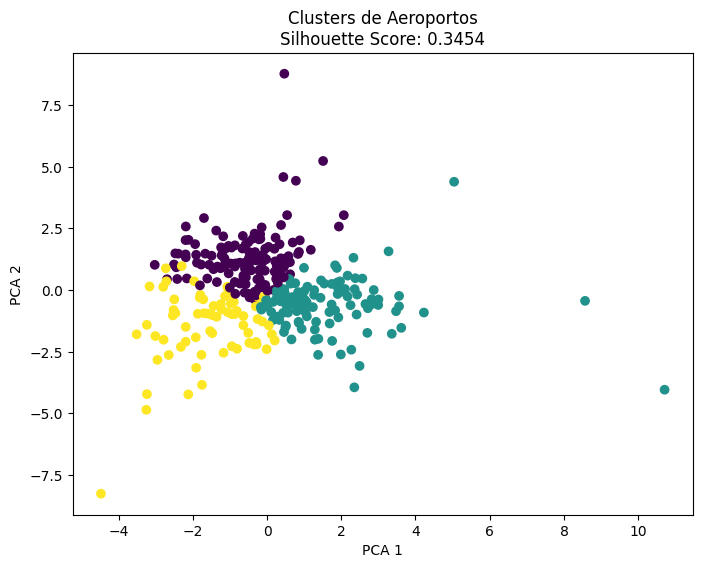

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title(f'Clusters de Aeroportos\nSilhouette Score: {score:.4f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

## Teste

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

# Selecionar variáveis numéricas relevantes
features = [
    "DISTANCE",
    "AIR_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "TAXI_OUT",
    "TAXI_IN"
]

data = df[features].dropna()

# Normalizar dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

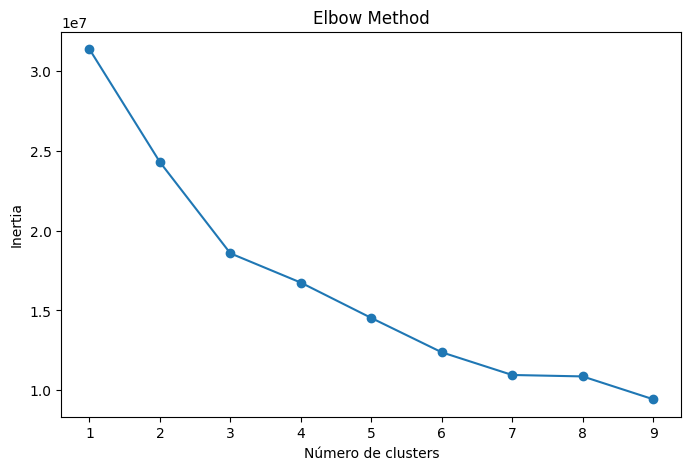

In [104]:
inertia = []

K = range(1,10)

for k in K:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")

plt.show()

In [114]:
kmeans = MiniBatchKMeans(
    n_clusters=3,
    batch_size=60000,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

data["cluster"] = clusters

In [115]:
score = silhouette_score(X_scaled, clusters, sample_size=60000, random_state=42)

print("Silhouette Score:", score)

Silhouette Score: 0.42110362893287645


In [116]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [117]:
X_pca = pca.transform(X_scaled)

In [118]:
X_scaled.shape

(5231130, 6)

In [119]:
X_pca.shape

(5231130, 2)

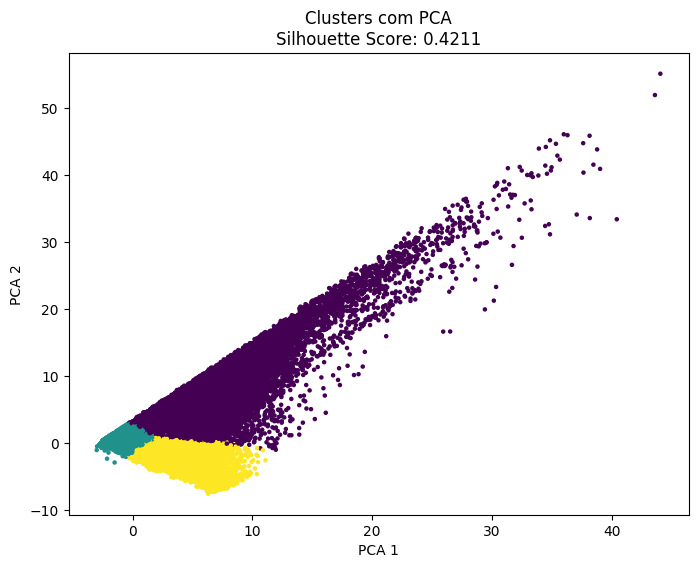

In [120]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=5)
plt.title(f'Clusters com PCA\nSilhouette Score: {score:.4f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [121]:
cluster_summary = data.groupby("cluster").mean()

print(cluster_summary)

            DISTANCE    AIR_TIME  DEPARTURE_DELAY  ARRIVAL_DELAY   TAXI_OUT  \
cluster                                                                       
0         768.812498  108.322485       127.508501     129.494758  21.612449   
1         579.893797   84.675708         2.588747      -2.135988  15.387242   
2        1851.245366  234.585058         4.968965      -2.156451  17.425573   

          TAXI_IN  
cluster            
0        8.721135  
1        7.091058  
2        8.464273  


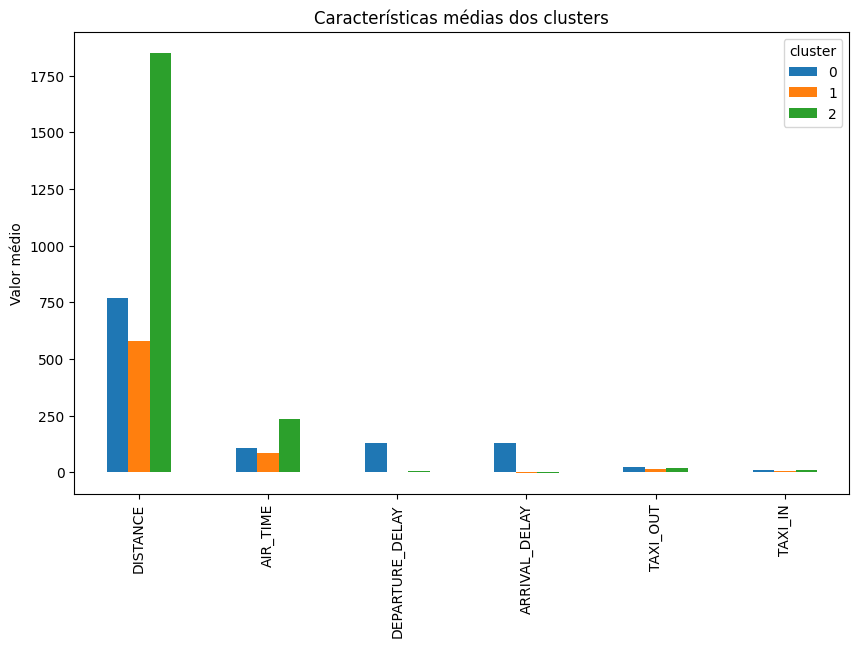

In [122]:
cluster_summary.T.plot(kind="bar", figsize=(10,6))
plt.title("Características médias dos clusters")
plt.ylabel("Valor médio")
plt.show()